2025-07-10 17:16:58,164 - INFO - LymphNodeMerger initialized with parameters:
2025-07-10 17:16:58,165 - INFO -   Distance threshold: 2.0 mm
2025-07-10 17:16:58,166 - INFO -   Contact area threshold: 10.0 mm²
2025-07-10 17:16:58,167 - INFO -   Intensity difference threshold: 0.2
2025-07-10 17:16:58,168 - INFO -   Dilation radius: 1 voxels
2025-07-10 17:16:58,169 - INFO -   Debug visualization: True
2025-07-10 17:16:58,170 - INFO - Loading MRI image from data/raw/images/1095-T2_FS_TRA+301.nii.gz
2025-07-10 17:16:58,521 - INFO - Loading annotation image from data/raw/labels/1095-T2_FS_TRA+301.nii.gz
2025-07-10 17:16:58,563 - INFO - Size match: True, Spacing match: True, Origin match: True
2025-07-10 17:16:58,565 - INFO - MRI spacing: (0.44920000433921814, 0.44920000433921814, 4.0), Anno spacing: (0.44920000433921814, 0.44920000433921814, 4.0)
2025-07-10 17:16:58,565 - INFO - Image spacing: (0.44920000433921814, 0.44920000433921814, 4.0)
2025-07-10 17:16:58,674 - INFO - Found 7 lymph node 

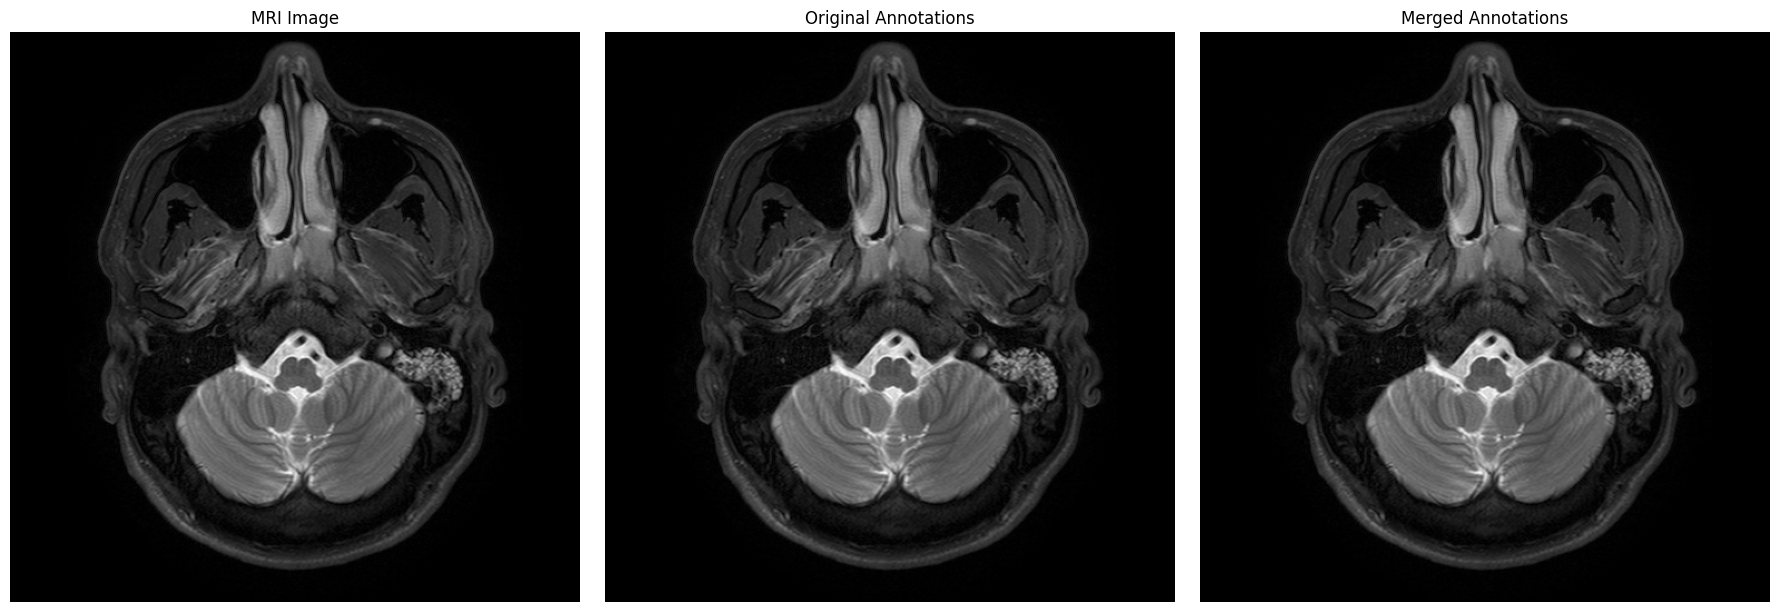

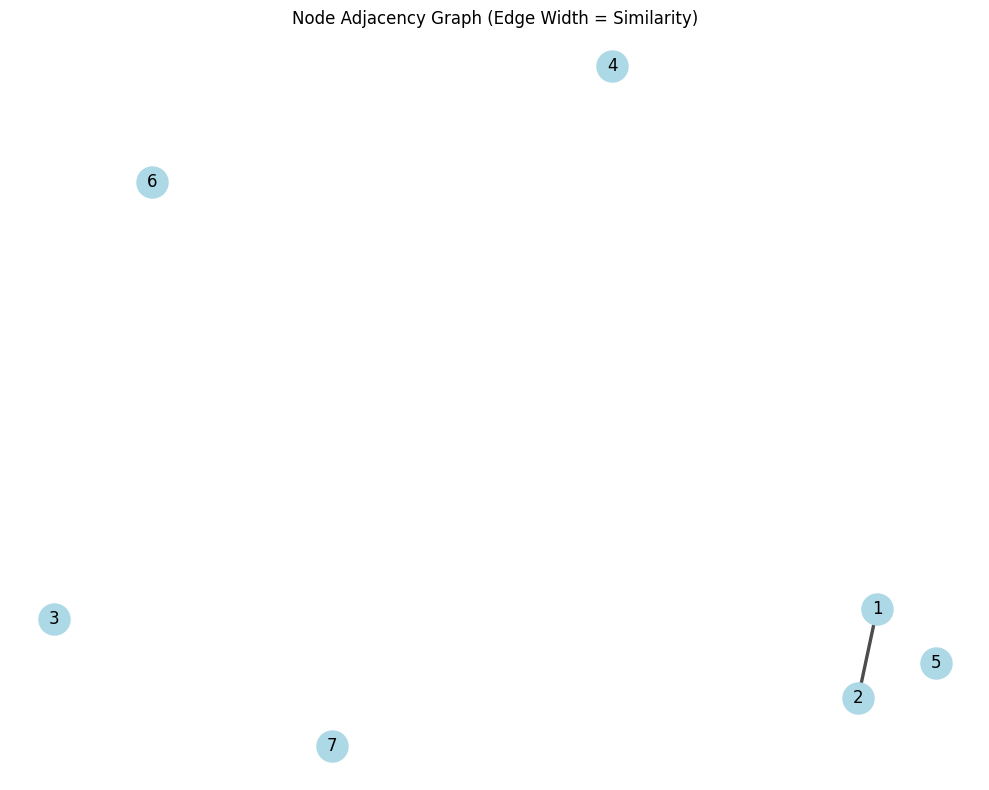

2025-07-10 17:17:04,209 - INFO - Visualizing all debug masks for slice 15


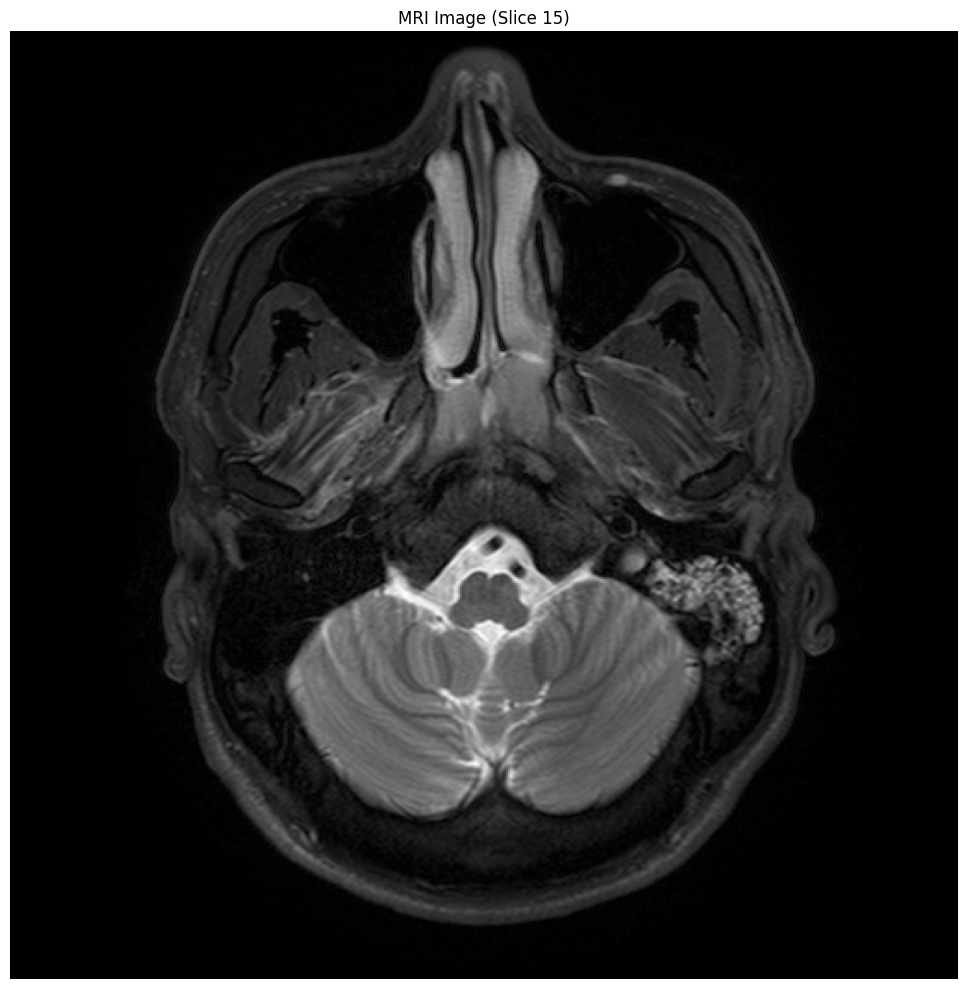

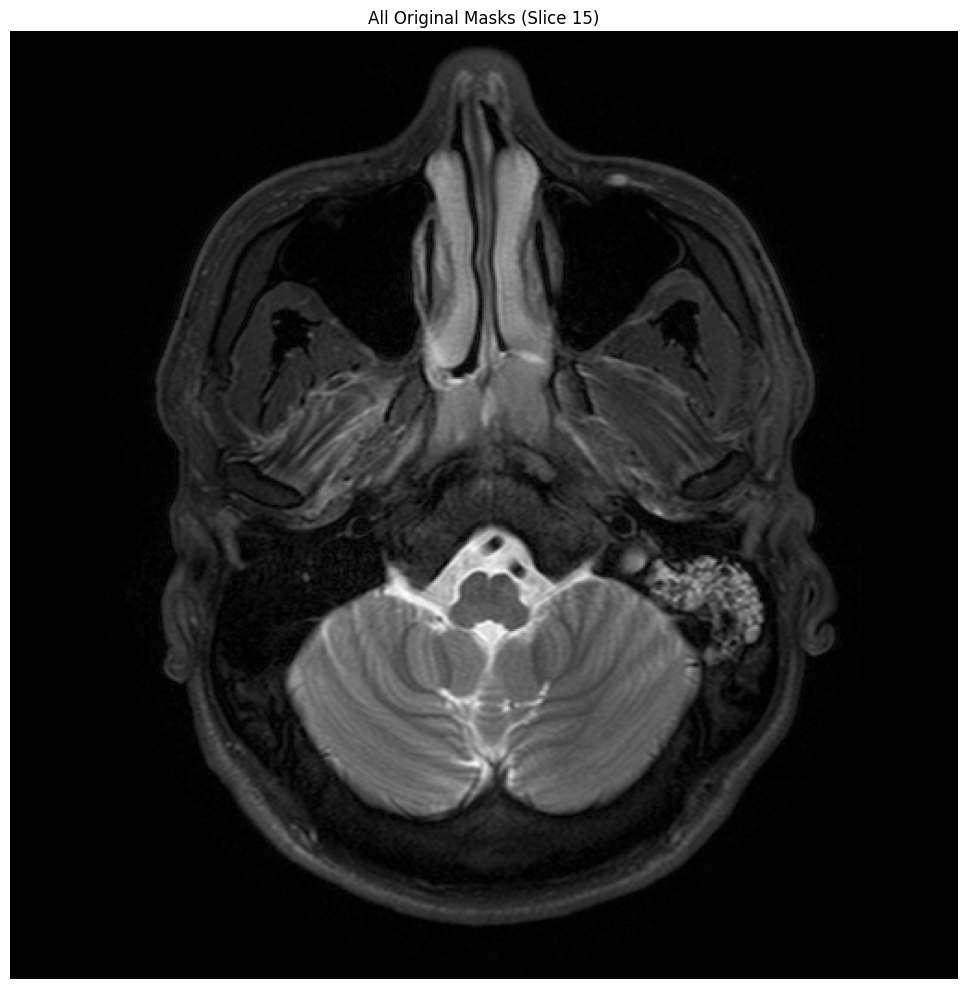

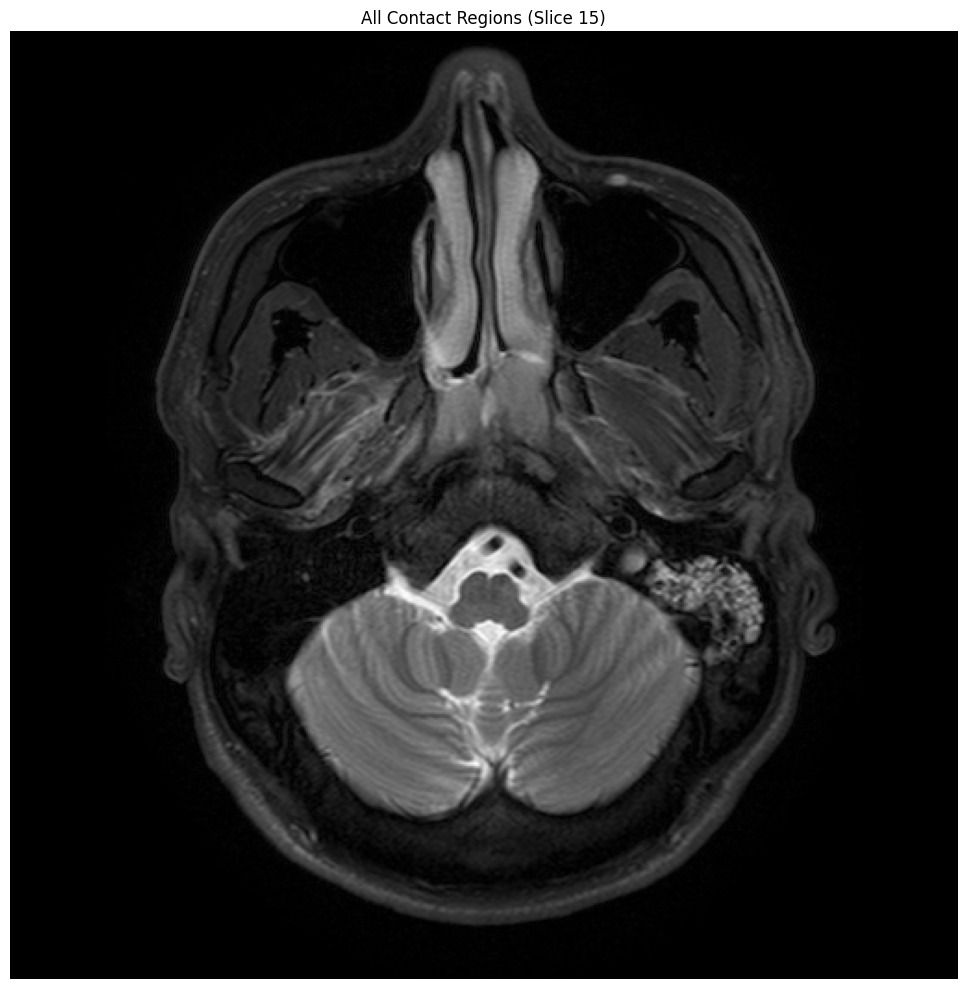

2025-07-10 17:17:05,651 - INFO - Saving merged annotations to test.nii.gz


In [10]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import ndimage
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, 
                    format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class LymphNodeMerger:
    def __init__(self, mri_path, annotation_path, 
                 distance_threshold=2.0,  # in mm
                 contact_area_threshold=10.0,  # in mm²
                 intensity_diff_threshold=0.2,  # relative threshold
                 dilation_radius=1,  # voxels
                 debug_visualization=False):  # Enable debug visualizations
        """
        Initialize the LymphNodeMerger with the given parameters.
        
        Parameters:
        -----------
        mri_path : str
            Path to the MRI image in NIFTI format
        annotation_path : str
            Path to the annotation image in NIFTI format
        distance_threshold : float
            Maximum distance (in mm) between nodes to be considered for merging
        contact_area_threshold : float
            Minimum contact surface area (in mm²) required for merging
        intensity_diff_threshold : float
            Maximum relative intensity difference allowed between nodes and contact region
        dilation_radius : int
            Radius for dilation operation in voxels
        debug_visualization : bool
            Enable visualization of masks and contact regions for debugging
        """
        self.mri_path = mri_path
        self.annotation_path = annotation_path
        self.distance_threshold = distance_threshold
        self.contact_area_threshold = contact_area_threshold
        self.intensity_diff_threshold = intensity_diff_threshold
        self.dilation_radius = dilation_radius
        self.debug_visualization = debug_visualization
        
        self.mri_image = None
        self.annotation_image = None
        self.spacing = None
        self.node_labels = None
        self.node_masks = {}
        self.node_stats = {}
        self.adjacency_graph = None
        
        # For storing debug visualization data
        self.debug_data = {}
        
        logger.info("LymphNodeMerger initialized with parameters:")
        logger.info(f"  Distance threshold: {distance_threshold} mm")
        logger.info(f"  Contact area threshold: {contact_area_threshold} mm²")
        logger.info(f"  Intensity difference threshold: {intensity_diff_threshold}")
        logger.info(f"  Dilation radius: {dilation_radius} voxels")
        logger.info(f"  Debug visualization: {debug_visualization}")
        
    def load_data(self):
        """Load MRI and annotation data."""
        logger.info(f"Loading MRI image from {self.mri_path}")
        self.mri_image = sitk.ReadImage(self.mri_path)
        
        logger.info(f"Loading annotation image from {self.annotation_path}")
        self.annotation_image = sitk.ReadImage(self.annotation_path)
        
        # Ensure same coordinate system
        if not self._check_coordinate_match():
            logger.warning("MRI and annotation images might not be in the same coordinate system!")
        
        self.spacing = self.mri_image.GetSpacing()
        logger.info(f"Image spacing: {self.spacing}")
        
        # Extract node labels
        np_annotation = sitk.GetArrayFromImage(self.annotation_image)
        self.node_labels = np.unique(np_annotation)
        self.node_labels = self.node_labels[self.node_labels > 0]  # Remove background
        
        logger.info(f"Found {len(self.node_labels)} lymph node annotations with labels: {self.node_labels}")
        
        # Create individual masks for each node
        self._create_node_masks()
        
        return self
    
    def _check_coordinate_match(self):
        """Check if MRI and annotation images have matching coordinate systems."""
        mri_size = self.mri_image.GetSize()
        anno_size = self.annotation_image.GetSize()
        mri_spacing = self.mri_image.GetSpacing()
        anno_spacing = self.annotation_image.GetSpacing()
        mri_origin = self.mri_image.GetOrigin()
        anno_origin = self.annotation_image.GetOrigin()
        
        size_match = mri_size == anno_size
        spacing_match = all(abs(m - a) < 1e-3 for m, a in zip(mri_spacing, anno_spacing))
        origin_match = all(abs(m - a) < 1e-3 for m, a in zip(mri_origin, anno_origin))
        
        logger.info(f"Size match: {size_match}, Spacing match: {spacing_match}, Origin match: {origin_match}")
        logger.info(f"MRI spacing: {mri_spacing}, Anno spacing: {anno_spacing}")

        
        return size_match and spacing_match and origin_match
    
    def _create_node_masks(self):
        """Create binary masks for each lymph node."""
        for label in self.node_labels:
            logger.info(f"Creating mask for node {label}")
            
            # Create binary mask for this node
            node_mask = sitk.Equal(self.annotation_image, int(label))
            self.node_masks[label] = node_mask
            
            # Calculate basic statistics for this node
            np_mri = sitk.GetArrayFromImage(self.mri_image)
            np_mask = sitk.GetArrayFromImage(node_mask)
            node_voxels = np_mri[np_mask > 0]
            
            if len(node_voxels) > 0:
                self.node_stats[label] = {
                    'mean_intensity': np.mean(node_voxels),
                    'std_intensity': np.std(node_voxels),
                    'volume_mm3': np.sum(np_mask) * np.prod(self.spacing),
                    'voxel_count': np.sum(np_mask)
                }
                logger.info(f"  Node {label} stats: {self.node_stats[label]}")
            else:
                logger.warning(f"  Node {label} has no voxels!")
    
    def analyze_node_pairs(self):
        """Analyze all pairs of nodes to determine potential merges."""
        logger.info("Starting node pair analysis")
        
        # Create a graph where nodes are lymph nodes and edges represent potential merges
        self.adjacency_graph = nx.Graph()
        for label in self.node_labels:
            self.adjacency_graph.add_node(label)
        
        # Analyze all unordered pairs
        node_pairs = [(a, b) for i, a in enumerate(self.node_labels) 
                     for b in self.node_labels[i+1:]]
        
        logger.info(f"Analyzing {len(node_pairs)} node pairs")
        
        for node_a, node_b in node_pairs:
            logger.info(f"Analyzing node pair ({node_a}, {node_b})")
            
            # Check minimum distance
            min_distance = self._calculate_min_distance(node_a, node_b)
            logger.info(f"  Minimum distance: {min_distance} mm")
            
            # Only proceed if distance is within threshold
            if min_distance > self.distance_threshold:
                logger.info("  Distance exceeds threshold, skipping further analysis")
                continue
            
            # Calculate contact surface area after dilation
            contact_area, contact_mask, dilated_a, dilated_b = self._calculate_contact_area(node_a, node_b)
            logger.info(f"  Contact surface area: {contact_area} mm²")
            
            # Store debug visualization data if enabled
            if self.debug_visualization:
                pair_key = f"{node_a}_{node_b}"
                if pair_key not in self.debug_data:
                    self.debug_data[pair_key] = {}
                
                self.debug_data[pair_key].update({
                    'original_a': self.node_masks[node_a],
                    'original_b': self.node_masks[node_b],
                    'dilated_a': dilated_a,
                    'dilated_b': dilated_b,
                    'contact_mask': contact_mask
                })
            
            if contact_area < self.contact_area_threshold:
                logger.info("  Contact area below threshold, skipping further analysis")
                continue
            
            # Check intensity similarity
            is_similar, similarity_score = self._check_intensity_similarity(node_a, node_b, contact_mask)
            logger.info(f"  Intensity similarity: {is_similar} (score: {similarity_score:.3f})")
            
            if is_similar:
                logger.info(f"  Adding edge between nodes {node_a} and {node_b}")
                self.adjacency_graph.add_edge(node_a, node_b, 
                                             distance=min_distance,
                                             contact_area=contact_area,
                                             similarity=similarity_score)
        
        return self
    
    def _calculate_min_distance(self, node_a, node_b):
        """Calculate minimum surface-to-surface distance between two nodes."""
        ## Get coordinates of mask voxels
        mask_a = sitk.GetArrayFromImage(self.node_masks[node_a]) > 0
        mask_b = sitk.GetArrayFromImage(self.node_masks[node_b]) > 0
        
        # If either mask is empty, return infinity
        if not np.any(mask_a) or not np.any(mask_b):
            return np.inf
        
        # Get coordinates of boundary voxels
        # A voxel is on the boundary if it's part of the mask and has at least one neighbor that isn't
        struct = ndimage.generate_binary_structure(3, 1)  # 3D connectivity
        eroded_a = ndimage.binary_erosion(mask_a, struct)
        boundary_a = mask_a & ~eroded_a
        
        eroded_b = ndimage.binary_erosion(mask_b, struct)
        boundary_b = mask_b & ~eroded_b
        
        # Get indices of boundary voxels
        boundary_a_indices = np.argwhere(boundary_a)
        boundary_b_indices = np.argwhere(boundary_b)
        
        # Convert indices to physical coordinates using spacing
        spacing_xyz = self.spacing[::-1]  # Convert from ITK to numpy format
        boundary_a_coords = boundary_a_indices * spacing_xyz
        boundary_b_coords = boundary_b_indices * spacing_xyz
        
        # Calculate minimum distance using KDTree for efficiency
        from scipy.spatial import KDTree
        tree_a = KDTree(boundary_a_coords)
        tree_b = KDTree(boundary_b_coords)
        
        # Find minimum distance from A to B
        min_dist_a_to_b = np.min(tree_a.query(boundary_b_coords)[0])
        
        # Find minimum distance from B to A
        min_dist_b_to_a = np.min(tree_b.query(boundary_a_coords)[0])
        
        return min(min_dist_a_to_b, min_dist_b_to_a)
    
    def _calculate_contact_area(self, node_a, node_b):
        """Calculate contact surface area between two nodes after dilation."""
        # Get original masks
        original_a = self.node_masks[node_a]
        original_b = self.node_masks[node_b]
        
        # Dilate both masks
        dilated_a = self._dilate_mask(original_a)
        dilated_b = self._dilate_mask(original_b)
        
        # Find intersection of dilated masks
        intersection = sitk.And(dilated_a, dilated_b)
        
        # Remove original masks from intersection to get only the contact region
        original_union = sitk.Or(original_a, original_b)
        contact_region = sitk.And(intersection, sitk.Not(original_union))
        
        # Calculate surface area
        np_contact = sitk.GetArrayFromImage(contact_region)
        voxel_volume = np.prod(self.spacing)
        contact_voxels = np.sum(np_contact)
        
        # Log contact region information
        logger.info(f"  Contact region: {contact_voxels} voxels")
        
        # Estimate surface area - this is an approximation
        # For a more accurate calculation, we would need to count boundary voxels
        contact_area = contact_voxels * voxel_volume**(2/3)
        
        return contact_area, contact_region, dilated_a, dilated_b
    
    def _dilate_mask(self, mask):
        """Dilate a binary mask."""
        # Get numpy array from the mask
        np_mask = sitk.GetArrayFromImage(mask)
        original_count = np.sum(np_mask > 0)
        
        # Perform dilation using scipy's binary_dilation
        struct_element = ndimage.generate_binary_structure(3, 1)  # 6-connectivity in 3D
        # For larger dilation radius, iterate the dilation
        dilated_mask = np_mask > 0
        for _ in range(self.dilation_radius):
            dilated_mask = ndimage.binary_dilation(dilated_mask, structure=struct_element)
        
        # Create SimpleITK image from dilated mask
        dilated_count = np.sum(dilated_mask)
        logger.info(f"  Dilation: {original_count} voxels -> {dilated_count} voxels " +
                f"(+{dilated_count - original_count}, {dilated_count / original_count:.2f}x)")
        
        # Convert back to SimpleITK
        dilated_sitk = sitk.GetImageFromArray(dilated_mask.astype(np.uint8))
        dilated_sitk.CopyInformation(mask)
        
        return dilated_sitk
    
    def _check_intensity_similarity(self, node_a, node_b, contact_mask):
        """Check if the intensity in the contact region is similar to the nodes."""
        # Get intensity values
        np_mri = sitk.GetArrayFromImage(self.mri_image)
        np_contact = sitk.GetArrayFromImage(contact_mask)
        
        # Extract intensities for each region
        if np.sum(np_contact) == 0:
            logger.warning("  Contact region is empty")
            return False, 0
            
        contact_intensities = np_mri[np_contact > 0]
        mean_contact = np.mean(contact_intensities)
        
        # Compare with node intensities
        mean_a = self.node_stats[node_a]['mean_intensity']
        mean_b = self.node_stats[node_b]['mean_intensity']
        
        # Calculate weighted average of node intensities
        weighted_mean = (mean_a * self.node_stats[node_a]['voxel_count'] + 
                         mean_b * self.node_stats[node_b]['voxel_count']) / \
                        (self.node_stats[node_a]['voxel_count'] + 
                         self.node_stats[node_b]['voxel_count'])
        
        # Calculate relative difference
        rel_diff = abs(mean_contact - weighted_mean) / weighted_mean
        
        # Check if intensity difference is within threshold
        is_similar = rel_diff <= self.intensity_diff_threshold
        
        return is_similar, 1 - rel_diff  # Convert to similarity score (0-1)
    
    def identify_matted_nodes(self):
        """Identify groups of matted nodes using connected components."""
        if self.adjacency_graph is None:
            logger.error("Node pair analysis has not been run yet!")
            return None
        
        # Find connected components in the adjacency graph
        connected_components = list(nx.connected_components(self.adjacency_graph))
        
        logger.info(f"Found {len(connected_components)} matted node groups:")
        for i, component in enumerate(connected_components):
            logger.info(f"  Group {i+1}: {component}")
        
        return connected_components
    
    def merge_annotations(self):
        """Merge annotations based on identified matted node groups."""
        matted_groups = self.identify_matted_nodes()
        
        if not matted_groups:
            logger.info("No matted node groups to merge")
            return self.annotation_image
        
        # Create a new label image by copying the original
        merged_annotation = sitk.Cast(self.annotation_image, self.annotation_image.GetPixelID())
        
        # Process each matted group
        for i, group in enumerate(matted_groups):
            if len(group) <= 1:
                logger.info(f"Skipping group {i+1} as it contains only one node")
                continue
                
            logger.info(f"Merging group {i+1}: {group}")
            
            # Create a new label for this group (use the minimum label in the group)
            new_label = min(group)
            
            # Create a mask for the entire group
            group_mask = sitk.Image(self.annotation_image.GetSize(), sitk.sitkUInt8)
            group_mask.CopyInformation(self.annotation_image)
            
            # Union all node masks in this group
            for node_label in group:
                if node_label != new_label:  # Skip the new label as it will stay the same
                    # Create a binary mask for this node
                    temp_mask = sitk.Equal(self.annotation_image, int(node_label))
                    
                    # Add to group mask
                    group_mask = sitk.Or(group_mask, temp_mask)
                    
                    # Remove the original node from the merged annotation by setting it to 0
                    # This is equivalent to: merged_annotation = sitk.Where(temp_mask, 0, merged_annotation)
                    zero_image = sitk.Image(merged_annotation.GetSize(), merged_annotation.GetPixelID())
                    zero_image.CopyInformation(merged_annotation)
                    
                    # Multiply inverted mask with merged annotation (sets masked areas to 0)
                    inverted_mask = sitk.Not(temp_mask)
                    merged_annotation = sitk.Multiply(
                        merged_annotation, 
                        sitk.Cast(inverted_mask, merged_annotation.GetPixelID())
                    )
            
            # Add the new label to the group areas
            # This is equivalent to: merged_annotation = sitk.Where(group_mask, new_label, merged_annotation)
            # First, create an image filled with the new label
            label_image = sitk.Image(merged_annotation.GetSize(), merged_annotation.GetPixelID())
            label_image.CopyInformation(merged_annotation)
            label_image = sitk.Add(label_image, float(new_label))
            
            # Then, use masking to combine: (mask * label_image) + ((1-mask) * merged_annotation)
            merged_annotation = sitk.Add(
                sitk.Multiply(
                    sitk.Cast(group_mask, merged_annotation.GetPixelID()),
                    label_image
                ),
                sitk.Multiply(
                    sitk.Cast(sitk.Not(group_mask), merged_annotation.GetPixelID()),
                    merged_annotation
                )
            )
        
        logger.info("Annotation merging completed")
        return merged_annotation
    
    def visualize_debug_masks(self, node_pair, slice_idx=None):
        """
        Visualize the original masks, dilated masks, and contact region for a pair of nodes.
        
        Parameters:
        -----------
        node_pair : tuple
            Tuple of two node labels (a, b)
        slice_idx : int, optional
            Index of the slice to visualize. If None, use the middle slice.
        """
        if not self.debug_visualization:
            logger.warning("Debug visualization is not enabled")
            return
        
        node_a, node_b = node_pair
        pair_key = f"{node_a}_{node_b}"
        
        if pair_key not in self.debug_data:
            logger.warning(f"No debug data for node pair {node_pair}")
            return
        
        # Get the debug data
        debug_data = self.debug_data[pair_key]
        
        # Get numpy arrays for visualization
        np_mri = sitk.GetArrayFromImage(self.mri_image)
        np_original_a = sitk.GetArrayFromImage(debug_data['original_a'])
        np_original_b = sitk.GetArrayFromImage(debug_data['original_b'])
        np_dilated_a = sitk.GetArrayFromImage(debug_data['dilated_a'])
        np_dilated_b = sitk.GetArrayFromImage(debug_data['dilated_b'])
        np_contact = sitk.GetArrayFromImage(debug_data['contact_mask'])
        
        # If slice_idx is not provided, find a slice with the contact region
        if slice_idx is None:
            # Find slices where the contact region exists
            contact_slices = np.where(np.sum(np_contact, axis=(1, 2)) > 0)[0]
            if len(contact_slices) > 0:
                slice_idx = contact_slices[len(contact_slices) // 2]
            else:
                # If no contact, find a slice with both nodes
                node_slices = np.where(np.sum(np_original_a, axis=(1, 2)) * 
                                    np.sum(np_original_b, axis=(1, 2)) > 0)[0]
                if len(node_slices) > 0:
                    slice_idx = node_slices[len(node_slices) // 2]
                else:
                    # Default to middle slice
                    slice_idx = np_mri.shape[0] // 2
            
        # Check slice index
        if slice_idx < 0 or slice_idx >= np_mri.shape[0]:
            logger.error(f"Invalid slice index: {slice_idx}")
            slice_idx = np_mri.shape[0] // 2
            
        logger.info(f"Visualizing debug masks for node pair {node_pair}, slice {slice_idx}")
        
        # Create figure with 2 rows and 3 columns
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        
        # Row 1: Original masks
        # MRI image
        axes[0, 0].imshow(np_mri[slice_idx], cmap='gray')
        axes[0, 0].set_title(f'MRI Image (Slice {slice_idx})')
        axes[0, 0].axis('off')
        
        # Original mask A
        axes[0, 1].imshow(np_mri[slice_idx], cmap='gray')
        mask_a = np_original_a[slice_idx] > 0
        overlay_a = np.zeros((*np_original_a[slice_idx].shape, 4))
        color_a = plt.cm.tab10(1)  # Blue
        overlay_a[mask_a] = color_a
        overlay_a[..., 3] = 0.5 * mask_a  # Transparency
        axes[0, 1].imshow(overlay_a)
        axes[0, 1].set_title(f'Original Mask Node {node_a} ({np.sum(mask_a)} px)')
        axes[0, 1].axis('off')
        
        # Original mask B
        axes[0, 2].imshow(np_mri[slice_idx], cmap='gray')
        mask_b = np_original_b[slice_idx] > 0
        overlay_b = np.zeros((*np_original_b[slice_idx].shape, 4))
        color_b = plt.cm.tab10(2)  # Green
        overlay_b[mask_b] = color_b
        overlay_b[..., 3] = 0.5 * mask_b  # Transparency
        axes[0, 2].imshow(overlay_b)
        axes[0, 2].set_title(f'Original Mask Node {node_b} ({np.sum(mask_b)} px)')
        axes[0, 2].axis('off')
        
        # Row 2: Dilated masks and contact region
        # Dilated mask A - show both original (outline) and dilated (fill)
        axes[1, 0].imshow(np_mri[slice_idx], cmap='gray')
        dilated_a = np_dilated_a[slice_idx] > 0
        # Create combined overlay with dilated area as semi-transparent and original as outline
        overlay_combined_a = np.zeros((*dilated_a.shape, 4))
        # Fill dilated area
        overlay_combined_a[dilated_a, :3] = color_a[:3]
        overlay_combined_a[dilated_a, 3] = 0.3  # Lower transparency for dilated area
        # Add original as solid outline
        from skimage import segmentation
        outline_a = segmentation.find_boundaries(mask_a, mode='outer')
        overlay_combined_a[outline_a, :3] = [1, 1, 1]  # White outline
        overlay_combined_a[outline_a, 3] = 1.0  # Solid outline
        axes[1, 0].imshow(overlay_combined_a)
        axes[1, 0].set_title(f'Dilated Mask Node {node_a} (+{np.sum(dilated_a) - np.sum(mask_a)} px)')
        axes[1, 0].axis('off')
        
        # Dilated mask B - show both original (outline) and dilated (fill)
        axes[1, 1].imshow(np_mri[slice_idx], cmap='gray')
        dilated_b = np_dilated_b[slice_idx] > 0
        # Create combined overlay with dilated area as semi-transparent and original as outline
        overlay_combined_b = np.zeros((*dilated_b.shape, 4))
        # Fill dilated area
        overlay_combined_b[dilated_b, :3] = color_b[:3]
        overlay_combined_b[dilated_b, 3] = 0.3  # Lower transparency for dilated area
        # Add original as solid outline
        outline_b = segmentation.find_boundaries(mask_b, mode='outer')
        overlay_combined_b[outline_b, :3] = [1, 1, 1]  # White outline
        overlay_combined_b[outline_b, 3] = 1.0  # Solid outline
        axes[1, 1].imshow(overlay_combined_b)
        axes[1, 1].set_title(f'Dilated Mask Node {node_b} (+{np.sum(dilated_b) - np.sum(mask_b)} px)')
        axes[1, 1].axis('off')
        
        # Contact region
        axes[1, 2].imshow(np_mri[slice_idx], cmap='gray')
        contact = np_contact[slice_idx] > 0
        overlay_contact = np.zeros((*np_contact[slice_idx].shape, 4))
        color_contact = plt.cm.tab10(0)  # Red
        overlay_contact[contact] = color_contact
        overlay_contact[..., 3] = 0.7 * contact  # Higher opacity for contact
        # Add both outlines for reference
        overlay_contact[outline_a, :3] = [1, 1, 1]  # White for node A
        overlay_contact[outline_a, 3] = 0.5
        overlay_contact[outline_b, :3] = [1, 1, 1]  # White for node B
        overlay_contact[outline_b, 3] = 0.5
        axes[1, 2].imshow(overlay_contact)
        axes[1, 2].set_title(f'Contact Region ({np.sum(contact)} px)')
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.suptitle(f'Debug Visualization for Nodes {node_a} and {node_b}', fontsize=16)
        plt.subplots_adjust(top=0.93)
        plt.show()
        
        # Print some statistics for debugging
        logger.info(f"Node {node_a}: Original size: {np.sum(np_original_a)} voxels, Dilated size: {np.sum(np_dilated_a)} voxels")
        logger.info(f"Node {node_b}: Original size: {np.sum(np_original_b)} voxels, Dilated size: {np.sum(np_dilated_b)} voxels")
        logger.info(f"Contact region: {np.sum(np_contact)} voxels")
        
        return self
    
    def visualize_all_debug_masks_for_slice(self, slice_idx=None):
        """
        Visualize all masks and contact regions for a specific slice.
        
        Parameters:
        -----------
        slice_idx : int, optional
            Index of the slice to visualize. If None, use the middle slice.
        """
        if not self.debug_visualization:
            logger.warning("Debug visualization is not enabled")
            return
        
        if not self.debug_data:
            logger.warning("No debug data available")
            return
        
        # Get numpy array for MRI
        np_mri = sitk.GetArrayFromImage(self.mri_image)
        
        # If slice_idx is not provided, use the middle slice
        if slice_idx is None:
            slice_idx = np_mri.shape[0] // 2
            
        # Check slice index
        if slice_idx < 0 or slice_idx >= np_mri.shape[0]:
            logger.error(f"Invalid slice index: {slice_idx}")
            slice_idx = np_mri.shape[0] // 2
            
        logger.info(f"Visualizing all debug masks for slice {slice_idx}")
        
        # Create figure for MRI base image
        plt.figure(figsize=(10, 10))
        plt.imshow(np_mri[slice_idx], cmap='gray')
        plt.title(f'MRI Image (Slice {slice_idx})')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Create overlay of all original masks
        plt.figure(figsize=(10, 10))
        plt.imshow(np_mri[slice_idx], cmap='gray')
        
        # Create a combined overlay for all original masks
        overlay = np.zeros((*np_mri[slice_idx].shape, 4))
        
        for label in self.node_labels:
            mask = sitk.GetArrayFromImage(self.node_masks[label])[slice_idx] > 0
            if np.any(mask):
                color = plt.cm.tab10(int(label) % 10)
                overlay[mask, :3] = color[:3]
                overlay[mask, 3] = 0.5  # Transparency
        
        plt.imshow(overlay)
        plt.title(f'All Original Masks (Slice {slice_idx})')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        # Create overlay of all contact regions
        plt.figure(figsize=(10, 10))
        plt.imshow(np_mri[slice_idx], cmap='gray')
        
        # Create a combined overlay for all contact regions
        overlay = np.zeros((*np_mri[slice_idx].shape, 4))
        
        for pair_key, debug_data in self.debug_data.items():
            node_a, node_b = map(int, pair_key.split('_'))
            contact = sitk.GetArrayFromImage(debug_data['contact_mask'])[slice_idx] > 0
            
            if np.any(contact):
                # Use a unique color for each contact region
                color_idx = (node_a + node_b) % 10
                color = plt.cm.tab10(color_idx)
                overlay[contact, :3] = color[:3]
                overlay[contact, 3] = 0.7  # Higher opacity
                
                # Add a text annotation near the contact region
                contact_coords = np.argwhere(contact)
                if len(contact_coords) > 0:
                    center = np.mean(contact_coords, axis=0).astype(int)
                    plt.text(center[1], center[0], f"{node_a}-{node_b}", 
                             color='white', fontsize=8, ha='center', va='center',
                             bbox=dict(boxstyle="round", fc="black", alpha=0.7))
        
        plt.imshow(overlay)
        plt.title(f'All Contact Regions (Slice {slice_idx})')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
        
        return self
    
    def visualize_results(self, slice_idx=None):
        """Visualize the original and merged annotations."""
        if not hasattr(self, 'merged_annotation'):
            logger.info("Running merge_annotations first")
            self.merged_annotation = self.merge_annotations()
        
        # Get numpy arrays for visualization
        np_mri = sitk.GetArrayFromImage(self.mri_image)
        np_original = sitk.GetArrayFromImage(self.annotation_image)
        np_merged = sitk.GetArrayFromImage(self.merged_annotation)
        
        # If slice_idx is not provided, use the middle slice
        if slice_idx is None:
            slice_idx = np_mri.shape[0] // 2
            
        # Check slice index
        if slice_idx < 0 or slice_idx >= np_mri.shape[0]:
            logger.error(f"Invalid slice index: {slice_idx}")
            slice_idx = np_mri.shape[0] // 2
            
        logger.info(f"Visualizing results for slice {slice_idx}")
        
        # Create figure
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # MRI image
        axes[0].imshow(np_mri[slice_idx], cmap='gray')
        axes[0].set_title('MRI Image')
        axes[0].axis('off')
        
        # Original annotation
        axes[1].imshow(np_mri[slice_idx], cmap='gray')
        mask = np_original[slice_idx] > 0
        overlay = np.zeros((*np_original[slice_idx].shape, 4))
        for label in self.node_labels:
            color = plt.cm.tab10(label % 10)
            label_mask = np_original[slice_idx] == label
            overlay[label_mask] = color
        overlay[..., 3] = 0.5 * mask  # Transparency
        axes[1].imshow(overlay)
        axes[1].set_title('Original Annotations')
        axes[1].axis('off')
        
        # Merged annotation
        axes[2].imshow(np_mri[slice_idx], cmap='gray')
        mask = np_merged[slice_idx] > 0
        overlay = np.zeros((*np_merged[slice_idx].shape, 4))
        unique_labels = np.unique(np_merged[slice_idx])
        unique_labels = unique_labels[unique_labels > 0]
        for label in unique_labels:
            color = plt.cm.tab10(label % 10)
            label_mask = np_merged[slice_idx] == label
            overlay[label_mask] = color
        overlay[..., 3] = 0.5 * mask  # Transparency
        axes[2].imshow(overlay)
        axes[2].set_title('Merged Annotations')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # If there are matted groups, visualize the graph
        if hasattr(self, 'adjacency_graph') and len(self.adjacency_graph.edges) > 0:
            plt.figure(figsize=(10, 8))
            pos = nx.spring_layout(self.adjacency_graph)
            
            # Draw nodes
            nx.draw_networkx_nodes(self.adjacency_graph, pos, 
                                  node_color='lightblue', 
                                  node_size=500)
            
            # Draw edges with weights based on similarity
            edge_weights = [self.adjacency_graph[u][v].get('similarity', 0.5) 
                           for u, v in self.adjacency_graph.edges()]
            
            nx.draw_networkx_edges(self.adjacency_graph, pos, 
                                  width=[w*3 for w in edge_weights],
                                  alpha=0.7)
            
            # Draw labels
            nx.draw_networkx_labels(self.adjacency_graph, pos, 
                                   font_size=12, 
                                   font_family='sans-serif')
            
            plt.title("Node Adjacency Graph (Edge Width = Similarity)")
            plt.axis('off')
            plt.tight_layout()
            plt.show()
        
        # If debug visualization is enabled, show debug visualizations
        if self.debug_visualization and self.debug_data:
            self.visualize_all_debug_masks_for_slice(slice_idx)
        
        return self
    
    def visualize_slice_browser(self):
        """
        Create an interactive slice browser to view different slices of the MRI and annotations.
        """
        from ipywidgets import interact, IntSlider
        import ipywidgets as widgets
        
        # Get numpy arrays
        np_mri = sitk.GetArrayFromImage(self.mri_image)
        num_slices = np_mri.shape[0]
        
        # Define the plotting function
        def plot_slice(slice_idx):
            # Create figure
            fig, ax = plt.subplots(1, 1, figsize=(10, 10))
            
            # MRI image
            ax.imshow(np_mri[slice_idx], cmap='gray')
            ax.set_title(f'MRI Image - Slice {slice_idx}')
            ax.axis('off')
            
            # If we have debug data, add contact regions
            if self.debug_visualization and self.debug_data:
                # Create a combined overlay for all contact regions
                overlay = np.zeros((*np_mri[slice_idx].shape, 4))
                
                for pair_key, debug_data in self.debug_data.items():
                    node_a, node_b = map(int, pair_key.split('_'))
                    contact = sitk.GetArrayFromImage(debug_data['contact_mask'])[slice_idx] > 0
                    
                    if np.any(contact):
                        color_idx = (node_a + node_b) % 10
                        color = plt.cm.tab10(color_idx)
                        overlay[contact, :3] = color[:3]
                        overlay[contact, 3] = 0.7  # Higher opacity
                        
                        # Add a text annotation
                        contact_coords = np.argwhere(contact)
                        if len(contact_coords) > 0:
                            center = np.mean(contact_coords, axis=0).astype(int)
                            ax.text(center[1], center[0], f"{node_a}-{node_b}", 
                                    color='white', fontsize=8, ha='center', va='center',
                                    bbox=dict(boxstyle="round", fc="black", alpha=0.7))
                
                ax.imshow(overlay)
            
            plt.tight_layout()
            plt.show()
        
        # Create the slider widget
        slider = IntSlider(
            min=0,
            max=num_slices-1,
            step=1,
            value=num_slices//2,
            description='Slice:',
            continuous_update=False
        )
        
        # Create the interactive widget
        interact(plot_slice, slice_idx=slider)
    
    def save_results(self, output_path):
        """Save the merged annotation to file."""
        if not hasattr(self, 'merged_annotation'):
            logger.info("Running merge_annotations first")
            self.merged_annotation = self.merge_annotations()
            
        logger.info(f"Saving merged annotations to {output_path}")
        sitk.WriteImage(self.merged_annotation, output_path)
        
        return self
    
    def run_pipeline(self, output_path=None, visualize=True, slice_idx=None):
        """Run the complete analysis pipeline."""
        (self.load_data()
             .analyze_node_pairs())
        
        self.merged_annotation = self.merge_annotations()
        
        if visualize:
            self.visualize_results(slice_idx)
            
        if output_path:
            self.save_results(output_path)
            
        return self

if __name__ == "__main__":
    mri_path = "data/raw/images/1095-T2_FS_TRA+301.nii.gz"
    annotation_path = "data/raw/labels/1095-T2_FS_TRA+301.nii.gz"
    output_path = "test.nii.gz"
    
    merger = LymphNodeMerger(
        mri_path=mri_path,
        annotation_path=annotation_path,
        distance_threshold=2.0,
        contact_area_threshold=10.0,
        intensity_diff_threshold=0.2,
        dilation_radius=1,
        debug_visualization=True  # Enable debug visualization
    )
    
    merger.run_pipeline(output_path=output_path)
    
    # To visualize specific node pairs, uncomment and modify:
    # merger.visualize_debug_masks((1, 2))  # Visualize node pair (1, 2)
    
    # To browse through slices interactively (works in Jupyter notebooks):
    # merger.visualize_slice_browser()

2025-07-10 17:17:17,228 - INFO - Visualizing debug masks for node pair (1, 2), slice 2


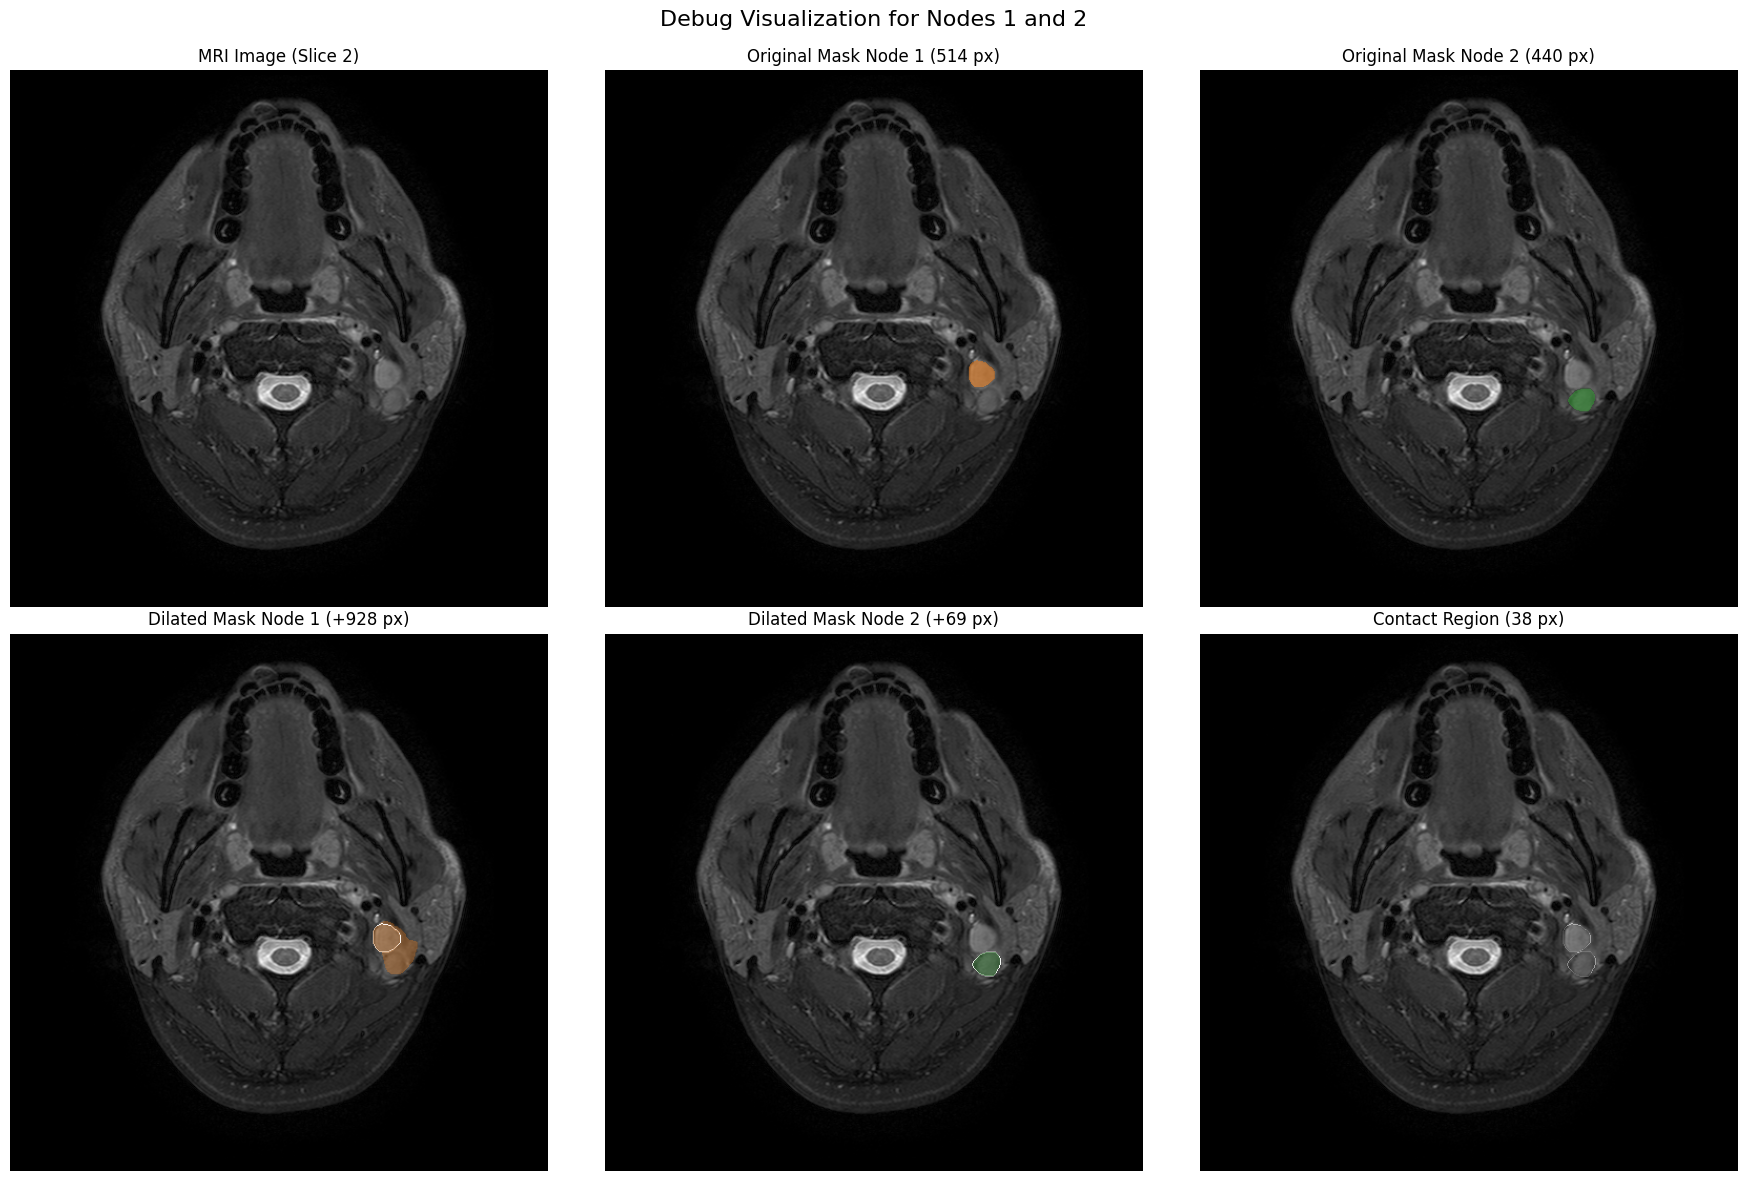

2025-07-10 17:17:18,390 - INFO - Node 1: Original size: 4182 voxels, Dilated size: 6364 voxels
2025-07-10 17:17:18,399 - INFO - Node 2: Original size: 789 voxels, Dilated size: 1816 voxels
2025-07-10 17:17:18,409 - INFO - Contact region: 102 voxels


In [12]:
merger.visualize_debug_masks((1, 2))